In [1]:
from pathlib import Path
import numpy as np
from tqdm import tqdm
import pickle
import warnings
from scipy import constants as cs
from abc import ABC, abstractmethod
import scipy
import sympy
from dataclasses import dataclass
from typing import Union, Callable
from matplotlib import pyplot as plt
from IPython.display import display

## Defining classes for carrying variables

In [2]:
Scalar = Union[float, int]
Field  = Union[Scalar, Callable[[np.ndarray], np.ndarray]]

@dataclass
class Drone:
    name: str
    N: int
    L_1: float
    L_2: float
    f_rot: float

@dataclass
class Radar:
    λ: float
    f_c: float

@dataclass
class Context:
    R:       Field
    V_rad:   Field
    θ:       Field
    Φ_p:     Field
    A_r:     Field
    snr:     Field
    t_start: float
    t_stop:  float
    dt:      float

    def resolve(self, field, t: np.ndarray) -> np.ndarray:
        return field(t) if callable(field) else np.full_like(t, field, dtype=float)

## Defining selected drones and radar

In [3]:
λ = 0.02998
default_radar = Radar(
    λ = λ,
    f_c = cs.c/λ
)


djimavicair2 = Drone(
    name="DJI_Mavic_Air_2",
    N=2,
    L_1=0.005,
    L_2=0.07,
    f_rot=91.66,
)

djimavicmini = Drone(
    name="DJI_Mavic_Mini",
    N=2,
    L_1=0.005,
    L_2=0.035,
    f_rot=160,
)

djimatrice300rtk = Drone(
    name="DJI_Matrice_300_RTK",
    N=2,
    L_1=0.05,
    L_2=0.2665,
    f_rot=70,
)

parrotdisco = Drone(
    name="Parrot_Disco",
    N=2,
    L_1=0.01,
    L_2=0.104,
    f_rot=40,
)

djiphantom4 = Drone(
    name="DJI_Phantom_4",
    N=2,
    L_1=0.006,
    L_2=0.05,
    f_rot=116,
)

class_map = ["DJI_Matrice_300_RTK", "DJI_Mavic_Air_2",
             "DJI_Mavic_Mini", "DJI_Phantom_4", "Parrot_Disco"]

drones_array = [djimatrice300rtk, djimavicair2, djimavicmini, djiphantom4, parrotdisco]

## Implementing noise models

In [4]:
class BaseNoiseModel(ABC):
    def __init__(self):
        self.params_set_flag = False

    @abstractmethod
    def set_parameters(self, params):
        pass

    @abstractmethod
    def apply_noise(self, signal, signal_params):
        pass

class AdditiveWhiteGaussianNoise(BaseNoiseModel):
    def __init__(self, sigma=None):
        super().__init__()
        if sigma is not None:
            self.sigma = sigma
            self.params_set_flag = True

    def set_parameters(self, params):
        if "sigma" in params.keys():
            self.sigma = params["sigma"]
            self.params_set_flag=True
        else:
            raise ValueError("A key with sigma value is not present in params dictionary")

    def apply_noise(self, signal, signal_params=None):
        noise = (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape)) * (self.sigma / np.sqrt(2))
        return signal+noise

    @classmethod
    def generate_noise(self, sigma, shape):
        noise = (np.random.randn(shape) + 1j * np.random.randn(shape)) * (sigma / np.sqrt(2))
        return noise

## Creation of synthetic data

In [5]:
class SyntheticSignalGenerator:
    def __init__(self, drone: Drone, radar: Radar, noise_model=None):
        self.drone = drone
        self.radar = radar
        self.noise_model = noise_model

        self.base_Psi_f = self._prepare_Psi_functions()

    def _prepare_sympy_Psi_function(self):
        theta, Phi_p, f_rot, t, lamb, A_r, f_c, R, V_rad, L_1, L_2 = sympy.symbols("θ Φ_p f_rot t λ A_r f_c, R, V_rad, L_1, L_2")
        n, N = sympy.symbols("n N", integer=True, positive=True)

        alpha = sympy.sin(sympy.Abs(theta) + Phi_p) + sympy.sin(sympy.Abs(theta) - Phi_p)
        beta  = sympy.sign(theta) * alpha
        Omega_n = 2 * sympy.pi * (f_rot * t + n / N)
        gamma_n = 4 * sympy.pi / lamb * sympy.cos(theta) * sympy.sin(Omega_n)

        first_part = A_r * sympy.exp(sympy.I*(2*sympy.pi*f_c*t - 4*sympy.pi/lamb*(R+V_rad*t)))

        # alpha, beta, Omega_n, gamma_n = sympy.symbols("α β Ω_n γ_n") # Just for verifying the equation

        element_second_part = (alpha + beta * sympy.cos(Omega_n)) * sympy.exp(-sympy.I*(L_1+L_2)/2) * sympy.sinc((L_2-L_1)/2*gamma_n)

        Psi = first_part + sympy.Sum(element_second_part, (n,1,N))

        # display(Phi)
        return Psi

    def _partially_substitute_Psi(self, Psi):
        theta, Phi_p, f_rot, t, lamb, A_r, f_c, R, V_rad, L_1, L_2 = sympy.symbols("θ Φ_p f_rot t λ A_r f_c, R, V_rad L_1 L_2")
        n, N = sympy.symbols("n N", integer=True, positive=True)

        subs = {
            f_rot: self.drone.f_rot,
            N:     self.drone.N,
            L_1:   self.drone.L_1,
            L_2:   self.drone.L_2,
            lamb:  self.radar.λ,
            f_c:   self.radar.f_c,

        }
        Psi_sub = Psi.subs(subs).doit()
        # display(Psi_sub)

        return Psi_sub

    def _prepare_Psi_functions(self):
        full_Psi = self._prepare_sympy_Psi_function()
        partially_substituted_Psi = self._partially_substitute_Psi(full_Psi)
        return partially_substituted_Psi

    def _lambidfy_Psi(self):
        t, R, V_rad, theta, Phi_p, A_r = sympy.symbols("t R V_rad θ Φ_p A_r")
        args = [t, A_r, Phi_p, R, V_rad, theta]
        return sympy.lambdify(args, self.base_Psi_f, "numpy")

    def set_noise_parameters(self, params):
        if self.noise_model is not None:
            self.noise_model.set_parameters(params)
        else:
            raise AttributeError("Error model was not set")

    def generate_signal(self, context, stft_form=True):
        if not isinstance(context, Context):
            raise ValueError("Provided context is not of Context class")
        # if (self.noise_model is not None) and self.noise_model.params_set_flag == False:
        #     raise AttributeError("The noise_model parameters were not set. Please set them with set_noise_parameters(signal_params)")

        Psi_f = self._lambidfy_Psi()
        # this is a re-arrangement of dB = 10\log_{10}{A_r^2/\sigma^2}
        sigma = context.A_r * np.power(10,-context.snr/20)
        self.set_noise_parameters({"sigma":sigma})
        t_array = np.arange(context.t_start,context.t_stop,context.dt)

        if self.noise_model is None or isinstance(self.noise_model, AdditiveWhiteGaussianNoise):
            R     = context.resolve(context.R,     t_array)
            V_rad = context.resolve(context.V_rad, t_array)
            θ     = context.resolve(context.θ,     t_array)
            Φ_p   = context.resolve(context.Φ_p,   t_array)
            A_r   = context.resolve(context.A_r,   t_array)
            signal = Psi_f(t_array, R, V_rad, θ, Φ_p, A_r)
            if isinstance(self.noise_model, AdditiveWhiteGaussianNoise):
                signal = self.noise_model.apply_noise(signal)

        else:       # Not tested, so this might throw errors
            signal = []
            for t in t_array:
                R     = context.resolve(context.R,     t)
                V_rad = context.resolve(context.V_rad, t)
                θ     = context.resolve(context.θ,     t)
                Φ_p   = context.resolve(context.Φ_p,   t)
                A_r   = context.resolve(context.A_r,   t)
                params = {
                    "t": t
                }
                signal.append(self.noise_model.apply_noise(Psi_f(t_array, R, V_rad, θ, Φ_p, A_r), params))
            signal = np.array(signal)

        if stft_form:
            stft_signal = self.apply_stft(signal, context)
            return t_array, stft_signal
        else:
            return t_array, signal

    def apply_stft(self, signal, context):
        f, t, Zreal = scipy.signal.stft(
        signal.real, 1/context.dt, window='hamming', nperseg=32, noverlap=16, return_onesided=True)
        Xreal = 20*np.log10(np.abs(Zreal))

        f, t, Zimag = scipy.signal.stft(
        signal.imag, 1/context.dt, window='hamming', nperseg=32, noverlap=16, return_onesided=True)
        Ximag = 20*np.log10(np.abs(Zimag))

        return np.stack((Xreal[1:,:], Ximag[1:,:]))

    def plot_drone_spectrogram(self, stft_signal, context):

        f_pts = stft_signal.shape[1]
        delta_t = 16 * context.dt
        delta_f = (1 / context.dt) / 32

        fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharex=True, sharey=True)
        fig.suptitle(f"Drone: {self.drone.name}")

        fig.supxlabel(f"Time t (dt={delta_t:g} s) [s]")
        fig.supylabel(f"Freq. f ({f_pts} bins, df={delta_f:g} Hz) [Hz]")

        im1 = axs[0].imshow(stft_signal[0], origin='lower', aspect='auto', cmap='viridis')
        axs[0].set_title("Real")
        fig.colorbar(im1, ax=axs[0], label="Magnitude |S(t,f)|")

        im2 = axs[1].imshow(stft_signal[1], origin='lower', aspect='auto', cmap='viridis')
        axs[1].set_title("Imag.")
        fig.colorbar(im2, ax=axs[1], label="Magnitude |S(t,f)|")

        fig.tight_layout()
        plt.show()

## Generating a sample

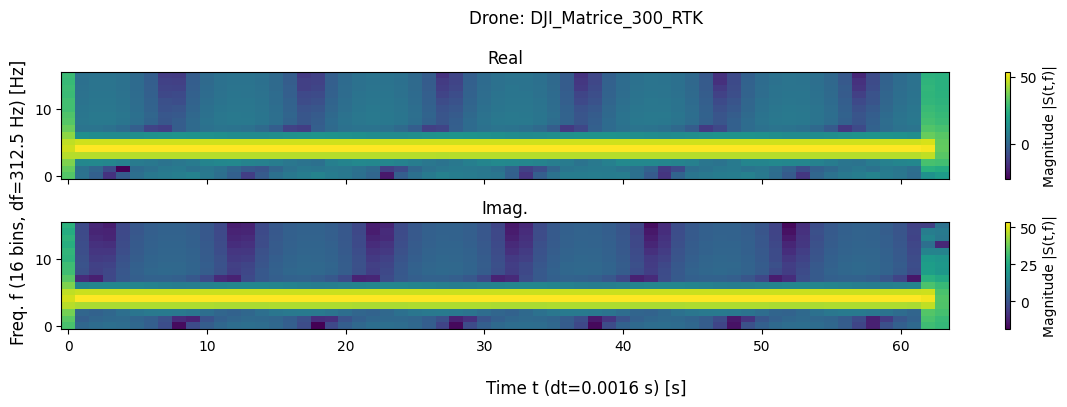

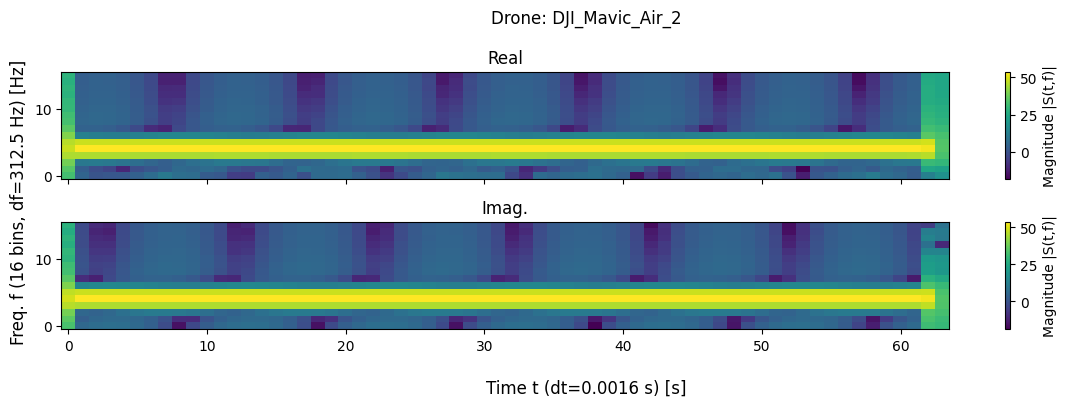

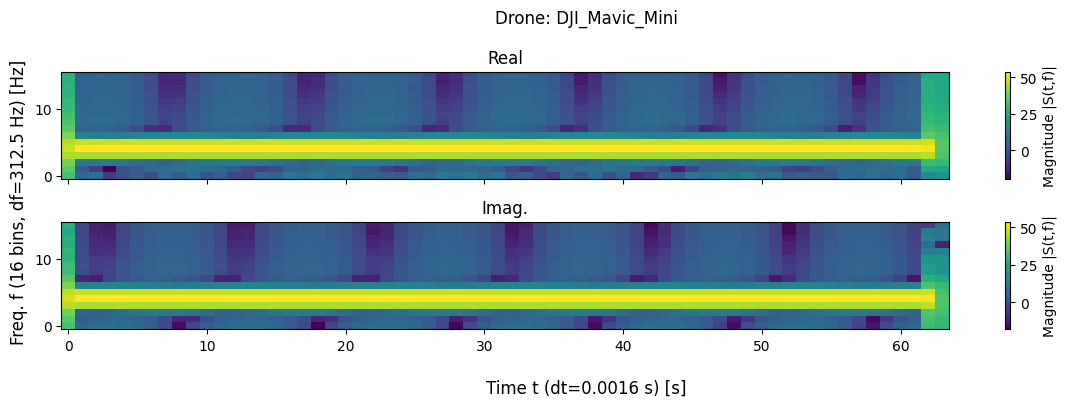

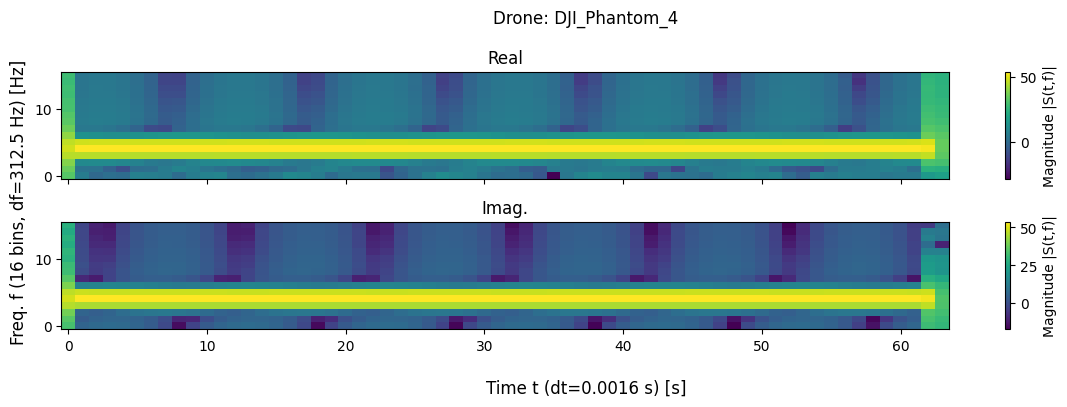

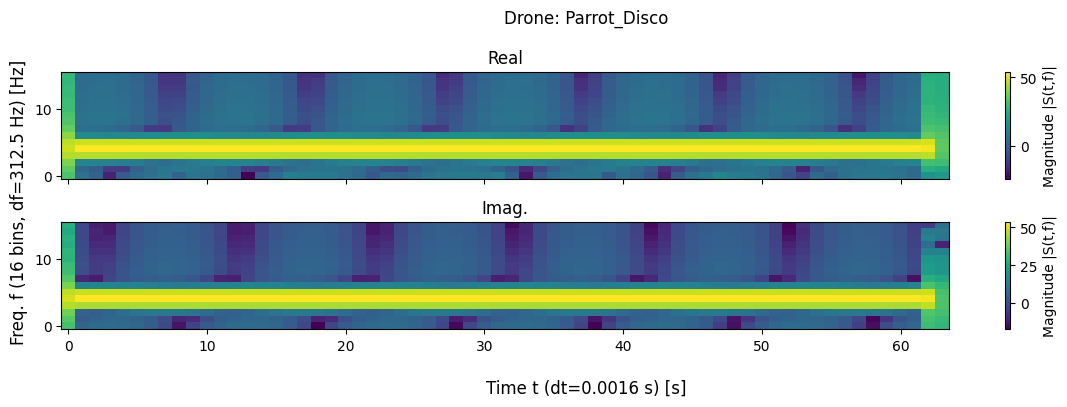

In [91]:
context = Context(
    R = 1000,
    V_rad = 25,
    θ = np.pi/8,
    Φ_p = np.pi/8,
    A_r = 1,
    snr = 20,
    t_start = 0,
    t_stop = 0.1,
    dt = 0.0001
)

awgn = AdditiveWhiteGaussianNoise()
for drone in drones_array:
    synt_signal_generator = SyntheticSignalGenerator(drone, default_radar, awgn)
    t_array,stft_y = synt_signal_generator.generate_signal(context)
    synt_signal_generator.plot_drone_spectrogram(stft_y, context)

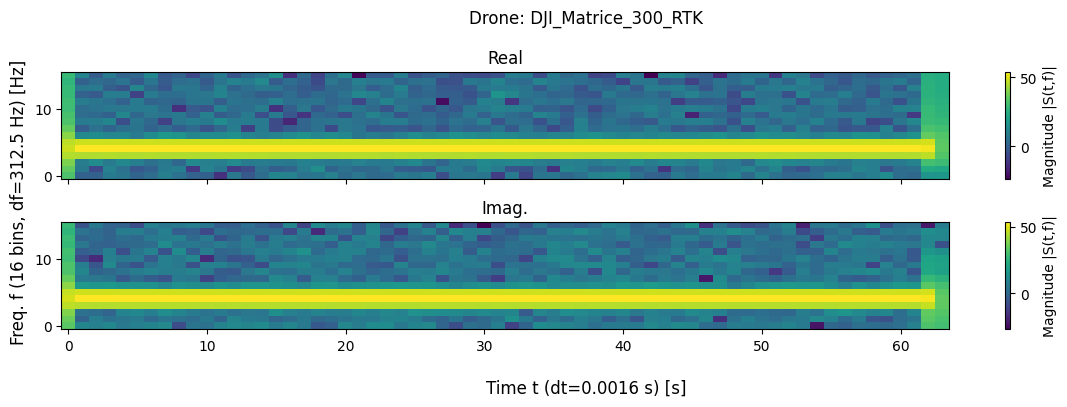

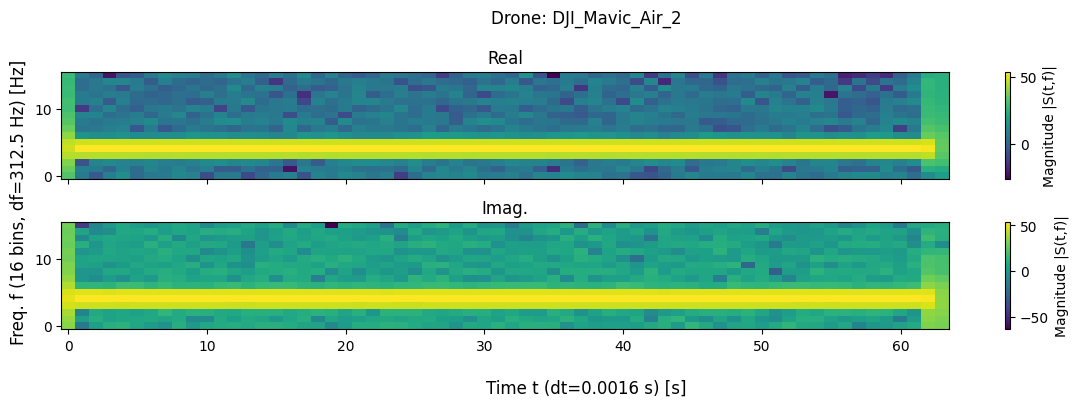

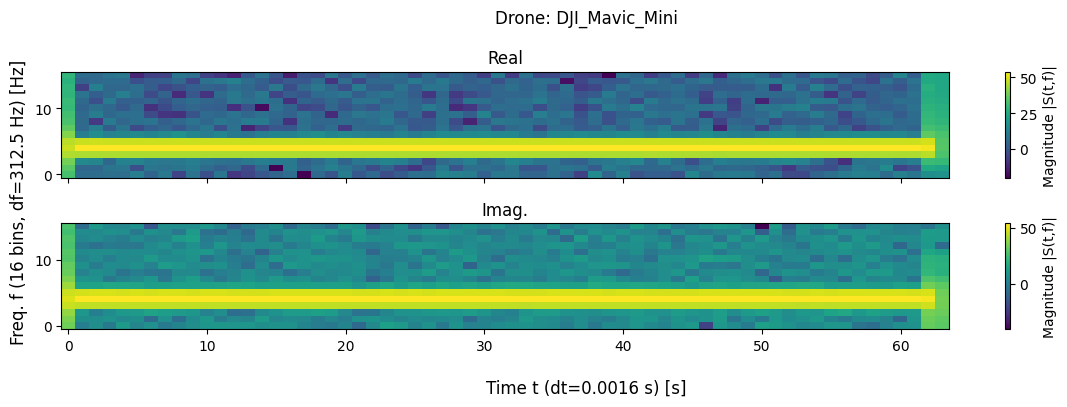

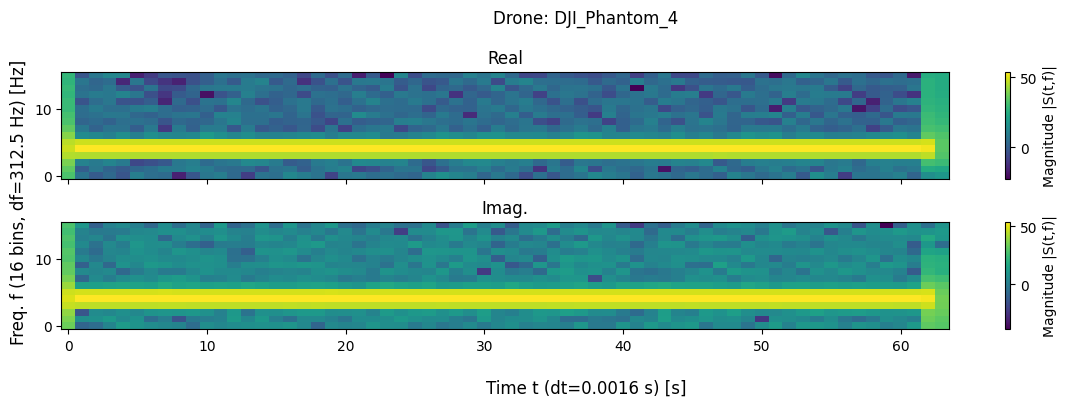

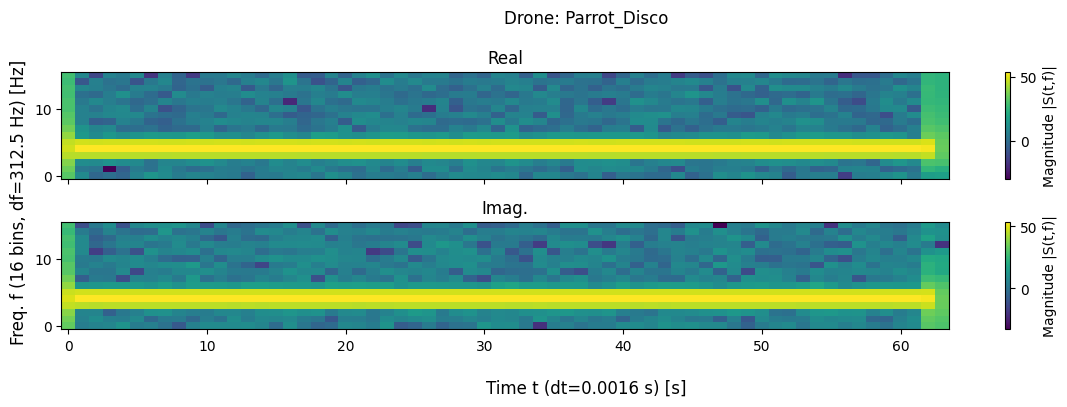

In [77]:
context = Context(
    R = 1000,
    V_rad = 25,
    θ = np.pi/8,
    Φ_p = np.pi/8,
    A_r = 1,
    snr = -20,
    t_start = 0,
    t_stop = 0.1,
    dt = 0.0001
)

awgn = AdditiveWhiteGaussianNoise()
for drone in drones_array:
    synt_signal_generator = SyntheticSignalGenerator(drone, default_radar, awgn)
    t_array,stft_y = synt_signal_generator.generate_signal(context)
    synt_signal_generator.plot_drone_spectrogram(stft_y, context)

## Classes for generating datasets

In [8]:
@dataclass
class DatasetMetadata:
    file_format:    str
    filename:       str
    save_path:      Path

    @classmethod
    def create_from_path(cls, path: Path):
        return cls(
            file_format=path.suffix.lstrip("."),
            filename=path.stem,
            save_path=path.parent
        )

@dataclass
class DataRequest:
    request_name:   str
    drone:          Drone
    radar:          Radar
    context:        Context
    noise_model:    BaseNoiseModel
    sample_size:    int

In [64]:
class SyntheticDatasetGenerator:
    def __init__(self, dataset_metadata: DatasetMetadata):
        self.dataset_metadata = dataset_metadata
        self.data_requests = []
        self._noise_config = None

        self._create_dataset_file()

    def _create_dataset_file(self):
        md = self.dataset_metadata
        full_path = md.save_path / f"{md.filename}.{md.file_format}"
        full_path.parent.mkdir(parents=True, exist_ok=True)

        if full_path.exists():
            warnings.warn(f"File '{full_path}' already exists. Resolving name conflict.")
            i = 1
            while full_path.exists():
                new_filename = f"{md.filename}_({i})"
                full_path = md.save_path / f"{new_filename}.{md.file_format}"
                i += 1
            self.dataset_metadata.filename = new_filename

        if md.file_format in ("pkl",):       # For now only pkl format has the native support
            full_path.touch()
        else:
            raise ValueError(f"Unsupported file format: {md.file_format}")


    def save_data(self, data, metadata):
        md = self.dataset_metadata
        full_path = md.save_path / f"{md.filename}.{md.file_format}"
        if md.file_format == "pkl":
            with open(full_path, "ab") as f:
                pickle.dump({"request": metadata, "signal": data}, f)
        else:
            raise ValueError(f"Unsupported file format: {md.file_format}")


    def append_data_requests(self, data_requests: list[DataRequest]):
        for item in data_requests:
            if not isinstance(item, DataRequest):
                raise TypeError("Submitted data_requests contain non DataRequest items")

        self.data_requests+=data_requests

    def set_noise_samples(self, n: int, t_len: float, dt: float):
        self._noise_config = (n, t_len, dt)


    def _generate_noise_data(self, file_handle, n: int, t_len: float, dt: float):
            noise_req_shape = int(t_len / dt)
            noise_metadata = DataRequest(
                request_name = "label=noise",
                drone        = None,
                radar        = None,
                context      = Context(
                    R=None, V_rad=None, θ=None, Φ_p=None,
                    A_r=None, snr=None, t_start=0, t_stop=t_len, dt=dt
                ),
                noise_model  = AdditiveWhiteGaussianNoise(),
                sample_size  = n
            )
            for _ in tqdm(range(n), desc="Noise samples"):
                noise_data = AdditiveWhiteGaussianNoise.generate_noise(sigma=1, shape=noise_req_shape)
                pickle.dump({"request": noise_metadata, "signal": noise_data}, file_handle)

    def generate_signal_data(self, stft_form=True):         # Can be further optimized with multiprocessing and buffering saving
        md = self.dataset_metadata
        full_path = md.save_path / f"{md.filename}.{md.file_format}"

        signal_count = sum(req.sample_size for req in self.data_requests)
        noise_count = self._noise_config[0] if self._noise_config is not None else 0
        dataset_len = signal_count + noise_count

        with open(full_path, "ab") as f:
            pickle.dump({"dataset_name": md.filename, "len": dataset_len}, f)

            with tqdm(total=signal_count, desc="Signal samples") as pbar:
                for req in self.data_requests:
                    sig_gen = SyntheticSignalGenerator(req.drone, req.radar, req.noise_model)
                    for _ in range(req.sample_size):
                        _, signal = sig_gen.generate_signal(req.context, stft_form)
                        pickle.dump({"request": req, "signal": signal}, f)
                        pbar.update(1)

            if self._noise_config is not None:
                n, t_start, dt = self._noise_config
                self._generate_noise_data(f, n, t_start, dt)

        self.data_requests = []
        self._noise_config = None

## Actual generation of datasets

### Training dataset

In [92]:
PROJECT_ROOT = Path().resolve()
path = PROJECT_ROOT  / "datasets" / "time_domain" / "training_dataset.pkl"
md = DatasetMetadata.create_from_path(path)

snr_values = np.arange(-60,40,5)
sample_size = 70
t_len = 0.1
dt = 0.0001

contexts_array = []
for snr in snr_values:
    contexts_array.append(Context(
        R = np.random.uniform(low=200, high=2000),
        V_rad = np.random.uniform(low=0, high=50),
        θ = np.random.uniform(low=np.pi/16, high=np.pi/2),
        Φ_p = np.random.uniform(low=0, high=np.pi/4),
        A_r = np.random.chisquare(4),
        snr = snr,
        t_start = 0,
        t_stop = t_len,
        dt = dt
    ))


data_requests_array = []
for cont in contexts_array:
    for drone in drones_array:
        data_req = DataRequest(
            request_name    = f"label={drone.name}",
            drone           = drone,
            radar           = default_radar,
            context         = cont,
            noise_model     = AdditiveWhiteGaussianNoise(),
            sample_size     = sample_size
        )
        data_requests_array.append(data_req)

dataset_gen = SyntheticDatasetGenerator(dataset_metadata=md)
dataset_gen.append_data_requests(data_requests=data_requests_array)
dataset_gen.set_noise_samples(n=sample_size*len(contexts_array),t_len=t_len ,dt=dt)
dataset_gen.generate_signal_data(stft_form=False)

Noise samples: 100%|██████████| 1400/1400 [00:00<00:00, 8065.29it/s]


### Validating dataset

In [93]:
PROJECT_ROOT = Path().resolve()
path = PROJECT_ROOT  / "datasets" / "time_domain" / "validating_dataset.pkl"
md = DatasetMetadata.create_from_path(path)

sample_size = 20

data_requests_array = []
for cont in contexts_array:
    for drone in drones_array:
        data_req = DataRequest(
            request_name    = f"label={drone.name}",
            drone           = drone,
            radar           = default_radar,
            context         = cont,
            noise_model     = AdditiveWhiteGaussianNoise(),
            sample_size     = sample_size
        )
        data_requests_array.append(data_req)

dataset_gen = SyntheticDatasetGenerator(dataset_metadata=md)
dataset_gen.append_data_requests(data_requests=data_requests_array)
dataset_gen.set_noise_samples(n=sample_size*len(contexts_array),t_len=t_len ,dt=dt)
dataset_gen.generate_signal_data(stft_form=False)

Noise samples: 100%|██████████| 400/400 [00:00<00:00, 8512.98it/s]


### Testing dataset

In [94]:
PROJECT_ROOT = Path().resolve()
path = PROJECT_ROOT  / "datasets" / "time_domain" / "testing_dataset.pkl"
md = DatasetMetadata.create_from_path(path)

sample_size = 10

data_requests_array = []
for cont in contexts_array:
    for drone in drones_array:
        data_req = DataRequest(
            request_name    = f"label={drone.name}",
            drone           = drone,
            radar           = default_radar,
            context         = cont,
            noise_model     = AdditiveWhiteGaussianNoise(),
            sample_size     = sample_size
        )
        data_requests_array.append(data_req)

dataset_gen = SyntheticDatasetGenerator(dataset_metadata=md)
dataset_gen.append_data_requests(data_requests=data_requests_array)
dataset_gen.set_noise_samples(n=sample_size*len(contexts_array),t_len=t_len ,dt=dt)
dataset_gen.generate_signal_data(stft_form=False)

Noise samples: 100%|██████████| 200/200 [00:00<00:00, 7440.80it/s]
